# Born effective charge diagonal - `sea-lr-eq_sA`

Per-atom diagonal elements `Z*_aa` (a = x, y, z) of the Born effective charge tensor, in **physical units**.

- model: `sea-lr-eq_sA/best_model.pth` (n_out=1, `remove_self_interaction=true`, `ChargeEqLatent` w=10)
- convention: **PBC dephased** (the periodic Z*)
- units: raw latent charge scaled by `sqrt(w * eps_inf)`, with `w = 0.02` (the long-range weight) and `eps_inf = 1.78` (high-frequency relative permittivity of water). This is cace's own convention - see `cace/modules/metalwall.py`: `Q^les = q / sqrt(eps_r)`.
- sign: fixed to the physical convention (Z*_O < 0). The overall sign of the learned charges is a gauge (`E_lr` is exact under `q -> -q`).

In [1]:
import os, sys
os.environ.setdefault("CUDA_VISIBLE_DEVICES", "")
os.environ.setdefault("DEEPMD_CACE_DEVICE", "cpu")

WS = "/root/app/deepmd-les/deepmd-les/desc_bridging"
sys.path.insert(0, WS)

import numpy as np
import torch
import check_bec as CB
import check_bec_arm as CBA

CKPT = os.path.join(WS, "..", "DeePMD-kit-FastLearn", "campaign_water_interface",
                    "deepmd", "runs", "sea-lr-eq_sA", "best_model.pth")
DATA = CB.DEFAULT_DATA
NFRAMES = 5
W_LR = 0.02            # long_range.weight in the arm's input.json
EPS_INF = 1.78         # high-frequency relative permittivity (water)
SCALE = float(np.sqrt(W_LR * EPS_INF))   # -> physical charge / BEC

model = CB.load_model(CKPT)
head = CB.charge_head_of(model)
elem, numbers = CB.read_system(DATA)
dtype = next(model.parameters()).dtype
numbers = torch.tensor(numbers)

diags = []
for index in range(NFRAMES):
    coord, box = CB.frame_tensors(DATA, index, dtype)
    n = coord.shape[0]
    pos = torch.tensor(coord, dtype=dtype, requires_grad=True)
    cell = torch.tensor(box, dtype=dtype).reshape(1, 3, 3)
    batch = torch.zeros(n, dtype=torch.int64)
    _, q_kernel = CBA.kernel_charges(model, head, pos, cell, batch, numbers)
    bec = CB.born_charges(pos, cell, batch, q_kernel, True)      # PBC dephased, [n, 3, 3]
    diags.append(np.diagonal(bec, axis1=1, axis2=2))             # Z*_aa, [n, 3]

# to physical units; sign flipped to the physical convention (Z*_O < 0)
Z = np.concatenate(diags, axis=0) * SCALE * -1.0                 # [NFRAMES * n, 3]
is_o, is_h = elem == "O", elem == "H"
mask_o, mask_h = np.tile(is_o, NFRAMES), np.tile(is_h, NFRAMES)
z_o, z_h = Z[mask_o].ravel(), Z[mask_h].ravel()

print(f"SCALE = sqrt(W_LR * EPS_INF) = sqrt({W_LR} * {EPS_INF}) = {SCALE:.4f}")
for name, z in (("O", z_o), ("H", z_h)):
    print(f"{name}: n={z.size}  mean={z.mean():+.3f} e  std={z.std():.3f} e  "
          f"p0.5={np.percentile(z, 0.5):+.2f}  p99.5={np.percentile(z, 99.5):+.2f}")

To get the best performance, it is recommended to adjust the number of threads by setting the environment variables OMP_NUM_THREADS, DP_INTRA_OP_PARALLELISM_THREADS, and DP_INTER_OP_PARALLELISM_THREADS. See https://deepmd.rtfd.io/parallelism/ for more information.


SCALE = sqrt(W_LR * EPS_INF) = sqrt(0.02 * 1.78) = 0.1887
O: n=7830  mean=-0.886 e  std=0.150 e  p0.5=-1.32  p99.5=-0.46
H: n=15660  mean=+0.446 e  std=0.163 e  p0.5=+0.14  p99.5=+0.99


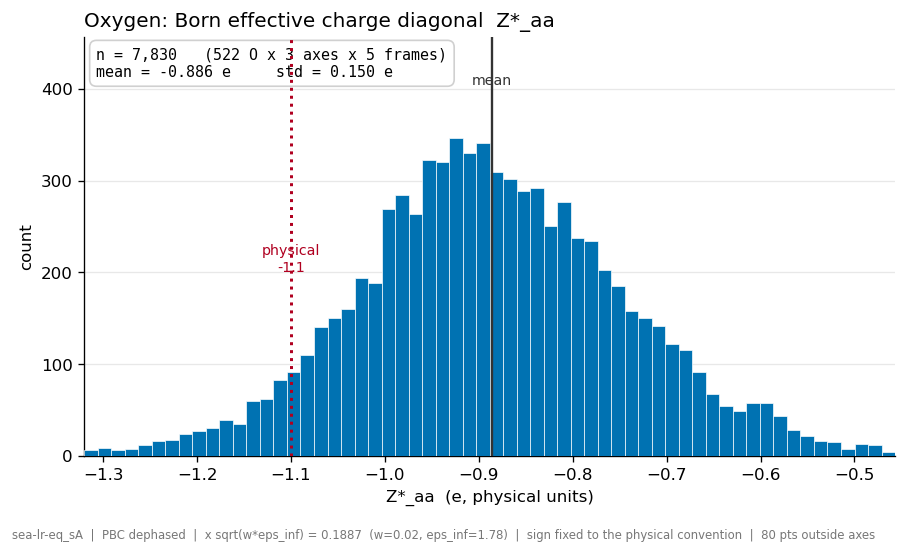

In [2]:
import matplotlib.pyplot as plt

O_COLOR = "#0072B2"     # Okabe-Ito blue
REF_O = -1.1            # physical Z*_O (literature range -1.1 to -1.3)

fig, ax = plt.subplots(figsize=(7.6, 4.6), dpi=120)
lo, hi = np.percentile(z_o, [0.5, 99.5])
clipped = int(((z_o < lo) | (z_o > hi)).sum())
counts, _, _ = ax.hist(z_o, bins=np.linspace(lo, hi, 61),
                       color=O_COLOR, edgecolor="white", linewidth=0.4, zorder=3)
ymax = counts.max()
ax.set_xlim(lo, hi)
ax.set_ylim(0, ymax * 1.32)

ax.axvline(z_o.mean(), color="#333333", lw=1.4, zorder=4)
ax.axvline(REF_O, color="#B00020", ls=":", lw=1.8, zorder=4)
ax.text(z_o.mean(), ymax * 1.17, "mean", color="#333333", fontsize=8.5, ha="center")
ax.text(REF_O, ymax * 0.62, "physical\n-1.1", color="#B00020", fontsize=8.5, ha="center", va="center")

ax.text(0.015, 0.975,
        f"n = {z_o.size:,}   ({int(is_o.sum())} O x 3 axes x {NFRAMES} frames)\n"
        f"mean = {z_o.mean():+.3f} e     std = {z_o.std():.3f} e",
        transform=ax.transAxes, va="top", ha="left", fontsize=9, family="monospace",
        bbox=dict(boxstyle="round,pad=0.45", fc="white", ec="#d0d0d0"))

ax.set_title("Oxygen: Born effective charge diagonal  Z*_aa", fontsize=12, loc="left")
ax.set_xlabel("Z*_aa  (e, physical units)")
ax.set_ylabel("count")
ax.grid(axis="y", color="#e8e8e8", lw=0.8, zorder=0)
ax.set_axisbelow(True)
for s in ("top", "right"):
    ax.spines[s].set_visible(False)

note = (f"sea-lr-eq_sA  |  PBC dephased  |  x sqrt(w*eps_inf) = {SCALE:.4f}  "
        f"(w={W_LR}, eps_inf={EPS_INF})  |  sign fixed to the physical convention"
        + (f"  |  {clipped} pts outside axes" if clipped else ""))
fig.text(0.012, 0.012, note, fontsize=7, color="#777777")
plt.tight_layout(rect=(0, 0.04, 1, 1))
plt.show()

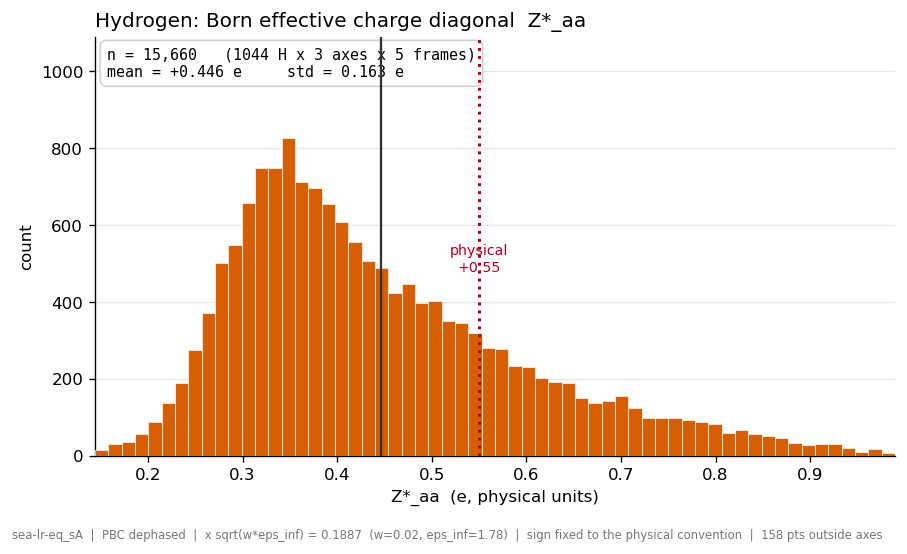

In [3]:
H_COLOR = "#D55E00"     # Okabe-Ito vermillion
REF_H = 0.55            # physical Z*_H

fig, ax = plt.subplots(figsize=(7.6, 4.6), dpi=120)
lo, hi = np.percentile(z_h, [0.5, 99.5])
clipped = int(((z_h < lo) | (z_h > hi)).sum())
counts, _, _ = ax.hist(z_h, bins=np.linspace(lo, hi, 61),
                       color=H_COLOR, edgecolor="white", linewidth=0.4, zorder=3)
ymax = counts.max()
ax.set_xlim(lo, hi)
ax.set_ylim(0, ymax * 1.32)

ax.axvline(z_h.mean(), color="#333333", lw=1.4, zorder=4)
ax.axvline(REF_H, color="#B00020", ls=":", lw=1.8, zorder=4)
ax.text(z_h.mean(), ymax * 1.17, "mean", color="#333333", fontsize=8.5, ha="center")
ax.text(REF_H, ymax * 0.62, "physical\n+0.55", color="#B00020", fontsize=8.5, ha="center", va="center")

ax.text(0.015, 0.975,
        f"n = {z_h.size:,}   ({int(is_h.sum())} H x 3 axes x {NFRAMES} frames)\n"
        f"mean = {z_h.mean():+.3f} e     std = {z_h.std():.3f} e",
        transform=ax.transAxes, va="top", ha="left", fontsize=9, family="monospace",
        bbox=dict(boxstyle="round,pad=0.45", fc="white", ec="#d0d0d0"))

ax.set_title("Hydrogen: Born effective charge diagonal  Z*_aa", fontsize=12, loc="left")
ax.set_xlabel("Z*_aa  (e, physical units)")
ax.set_ylabel("count")
ax.grid(axis="y", color="#e8e8e8", lw=0.8, zorder=0)
ax.set_axisbelow(True)
for s in ("top", "right"):
    ax.spines[s].set_visible(False)

note = (f"sea-lr-eq_sA  |  PBC dephased  |  x sqrt(w*eps_inf) = {SCALE:.4f}  "
        f"(w={W_LR}, eps_inf={EPS_INF})  |  sign fixed to the physical convention"
        + (f"  |  {clipped} pts outside axes" if clipped else ""))
fig.text(0.012, 0.012, note, fontsize=7, color="#777777")
plt.tight_layout(rect=(0, 0.04, 1, 1))
plt.show()